<a href="https://colab.research.google.com/github/k-zannnne/mliot-pyml-2026-hw/blob/main/week02/numpy_pandas_eda_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [ ]:
STUDENT_NAME = "Đặng Ngọc Khánh Vân"  # TODO: Họ và tên
STUDENT_ID = "24521975"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Đặng Ngọc Khánh Vân (24521975)


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

FileNotFoundError: Không tìm thấy data/automobile_raw.csv

## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [ ]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [ ]:
# TODO N1
max_row=np.max(logits, axis=1, keepdims=True)
shifted_logits=logits-max_row
exp_logits = np.exp(shifted_logits)
sum_row=np.sum(exp_logits, axis=1, keepdims=True)
class_probabilities = exp_logits/sum_row
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = class_probabilities[np.arange(len(logits)), predicted_classes]
print(shifted_logits)
print(class_probabilities)
print(predicted_classes)
print(confidence_scores)

[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
[0 1 2 0]
[0.65900114 0.66524096 0.97555875 0.33333333]


In [ ]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [ ]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [ ]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train-train_feature_mean)/train_feature_std
X_val_scaled = (X_val-train_feature_mean)/train_feature_std
print(train_feature_mean)
print(train_feature_std)
print(X_train_scaled)
print(X_val_scaled)

[172.5         69.16666667   1.65        28.16666667]
[ 7.47774476 13.04372987  0.79109629  7.64671316]
[[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
[[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [6]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

Complete N2 to run this self-check.


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [7]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [8]:
# TODO N3
correct_mask = (predicted_classes==true_labels)
high_confidence_mask = (confidence_scores>=0.7)
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.where(review_mask)[0]
print(correct_mask)
print(high_confidence_mask)
print(review_mask)
print(review_indices)

[ True False  True False]
[False False  True False]
[ True  True False  True]
[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [9]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [10]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32)/255.0
augmented_batch = np.flip(normalized_batch, axis=2)
augmented_batch[0, 0, 0, 0] = 1.0
print(normalized_batch)
print(augmented_batch)

[[[[0.         0.00392157 0.00784314]
   [0.01176471 0.01568628 0.01960784]
   [0.02352941 0.02745098 0.03137255]
   [1.         0.03921569 0.04313726]]

  [[0.04705882 0.05098039 0.05490196]
   [0.05882353 0.0627451  0.06666667]
   [0.07058824 0.07450981 0.07843138]
   [0.08235294 0.08627451 0.09019608]]

  [[0.09411765 0.09803922 0.10196079]
   [0.10588235 0.10980392 0.11372549]
   [0.11764706 0.12156863 0.1254902 ]
   [0.12941177 0.13333334 0.13725491]]

  [[0.14117648 0.14509805 0.14901961]
   [0.15294118 0.15686275 0.16078432]
   [0.16470589 0.16862746 0.17254902]
   [0.1764706  0.18039216 0.18431373]]]


 [[[0.1882353  0.19215687 0.19607843]
   [0.2        0.20392157 0.20784314]
   [0.21176471 0.21568628 0.21960784]
   [0.22352941 0.22745098 0.23137255]]

  [[0.23529412 0.23921569 0.24313726]
   [0.24705882 0.2509804  0.25490198]
   [0.25882354 0.2627451  0.26666668]
   [0.27058825 0.27450982 0.2784314 ]]

  [[0.28235295 0.28627452 0.2901961 ]
   [0.29411766 0.29803923 0.3019608 

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mối dòng đại diện cho một mẫu xe gồm các thông tin chi tiết về xe như tên hãng, kích thước,...
2. Ký hiệu missing value trong csv là dấu chấm hỏi.
3. symboling là mức độ rủi ro số càng lớn mức độ rủi ro càng cao và ngược lại.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [11]:
# TODO D1
raw_df = pd.read_csv('automobile_raw.csv')
raw_shape = raw_df.shape
raw_missing_marker_count=(raw_df=='?').sum().sum()
print(raw_df)
print(raw_shape)
print(raw_missing_marker_count)

     symboling normalized_losses         make fuel_type aspiration num_doors  \
0            3                 ?  alfa-romero       gas        std       two   
1            3                 ?  alfa-romero       gas        std       two   
2            1                 ?  alfa-romero       gas        std       two   
3            2               164         audi       gas        std      four   
4            2               164         audi       gas        std      four   
..         ...               ...          ...       ...        ...       ...   
200         -1                95        volvo       gas        std      four   
201         -1                95        volvo       gas      turbo      four   
202         -1                95        volvo       gas        std      four   
203         -1                95        volvo    diesel      turbo      four   
204         -1                95        volvo       gas      turbo      four   

      body_style drive_wheels engine_lo

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [13]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [14]:
# TODO D2
df_clean = raw_df.fillna(np.nan)
for column in NUMERIC_COLUMNS:
  if column in df_clean.columns:
    df_clean[column]=pd.to_numeric(df_clean[column], errors='coerce')
missing_by_column = df_clean.isna().sum()
print(df_clean)
print(missing_by_column)

     symboling  normalized_losses         make fuel_type aspiration num_doors  \
0            3                NaN  alfa-romero       gas        std       two   
1            3                NaN  alfa-romero       gas        std       two   
2            1                NaN  alfa-romero       gas        std       two   
3            2              164.0         audi       gas        std      four   
4            2              164.0         audi       gas        std      four   
..         ...                ...          ...       ...        ...       ...   
200         -1               95.0        volvo       gas        std      four   
201         -1               95.0        volvo       gas      turbo      four   
202         -1               95.0        volvo       gas        std      four   
203         -1               95.0        volvo    diesel      turbo      four   
204         -1               95.0        volvo       gas      turbo      four   

      body_style drive_whee

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì điều này sẽ dẫn đến sai lệch bản chất (không thể điền giá trị trung bình cột này cho cột khác) và không thể điền random một giá trị sẽ làm xuất hiện điểm bất thường trên biểu đồ phân phối.
- Việc chọn drop không gây ảnh hưởng lớn vì số lượng dòng thiếu rất ít nên xóa vài dòng không ảnh hưởng quá nhiều đến model.
- Thiếu nhiều dữ liệu hơn cột khác, không thể drop vì điều này làm mất đi lượng data lớn dẫn đến kết quả sai và nếu fill thì có thể gây nhiễu.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [15]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [16]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].values.astype(np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto-auto_feature_mean)/auto_feature_std
print(X_auto)
print(auto_feature_mean)
print(auto_feature_std)
print(X_auto_scaled)

[[2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.3495e+04]
 [2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.6500e+04]
 [2.8230e+03 1.5200e+02 1.5400e+02 1.9000e+01 2.6000e+01 1.6500e+04]
 ...
 [3.0120e+03 1.7300e+02 1.3400e+02 1.8000e+01 2.3000e+01 2.1485e+04]
 [3.2170e+03 1.4500e+02 1.0600e+02 2.6000e+01 2.7000e+01 2.2470e+04]
 [3.0620e+03 1.4100e+02 1.1400e+02 1.9000e+01 2.5000e+01 2.2625e+04]]
[ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ]
[5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03]
[[-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.03160942]
 [-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.40918671]
 [ 0.51484142  0.60449348  1.35087746 -0.96354805 -0.68549391  0.40918671]
 ...
 [ 0.87932089  1.10872067  0.81696561 -1.11893383 -1.12459248  1.03555038]
 [ 1.27465576  0.43641775  0.06948903  0.12415246 -0.53912772  1.15931531]
 [ 0.97574403 

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [17]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z= (X_auto[:, price_index]-np.mean(X_auto[:, price_index]))/np.std(X_auto[:, price_index])
price_outlier_mask=np.abs(price_z)>2
price_outliers = X_auto[price_outlier_mask]
print(price_z)
print(price_outlier_mask)
print(price_outliers)

[ 0.03160942  0.40918671  0.40918671  0.08878002  0.52855391  0.25212461
  0.56122283  0.71325894  1.33585312  0.40039123  0.46258783  0.97084079
  0.9878035   1.4225514   2.20095117  3.52718357  2.96992723 -1.01681153
 -0.87306829 -0.83788638 -0.96391301 -0.86276502 -0.66423852 -0.88136117
 -0.82318537 -0.70796461 -0.58872306 -0.54311223 -0.03511056 -0.84994875
 -0.80270447 -0.9856504  -0.84366626 -0.76827646 -0.74741861 -0.74741861
 -0.6720288  -0.52124918 -0.5526616  -0.37046956 -0.03749791 -0.36418708
 -0.81149995 -0.27585535  2.3881692   2.80281315  2.85935551 -1.01128294
 -0.89819823 -0.81024345 -0.82280842 -0.73485364 -0.28879727 -0.17571256
  0.05045687  0.30175623 -0.5526616  -0.59663899 -0.33277466 -0.37675205
 -0.30764472 -0.25110237  0.63284315  0.64088473  1.54656763  1.88531917
  1.8762724   2.30649691  2.63117569  2.74074221  3.48257793  4.04046252
  0.40956366 -0.9869069  -0.88638716 -0.82607531 -0.69791263 -0.41268786
 -0.59613639 -0.07720321  0.20425208  0.1565052  -0

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [18]:
# TODO D5
engine_price_corr = np.corrcoef(X_auto[:, 1], X_auto[:, -1])
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()
print(engine_price_corr)
print(price_by_body_style)

[[1.         0.87388695]
 [0.87388695 1.        ]]
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

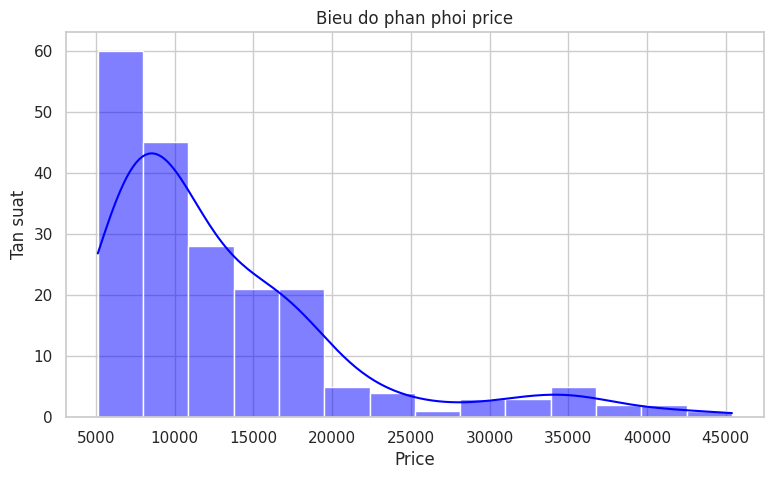

In [19]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(9, 5))
sns.histplot(data=df_clean, color='blue', x='price', kde=True)
plt.title('Bieu do phan phoi price')
plt.xlabel('Price')
plt.ylabel('Tan suat')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Đỉnh đồ thị ở phân khúc 7000 đô đến 8000 đô, đây là giá phổ biến của mẫu xe và tụt dốc về phía phải. Đây là phân phối lệch phải.

## M2.2 Dataset có cân bằng theo body style không?

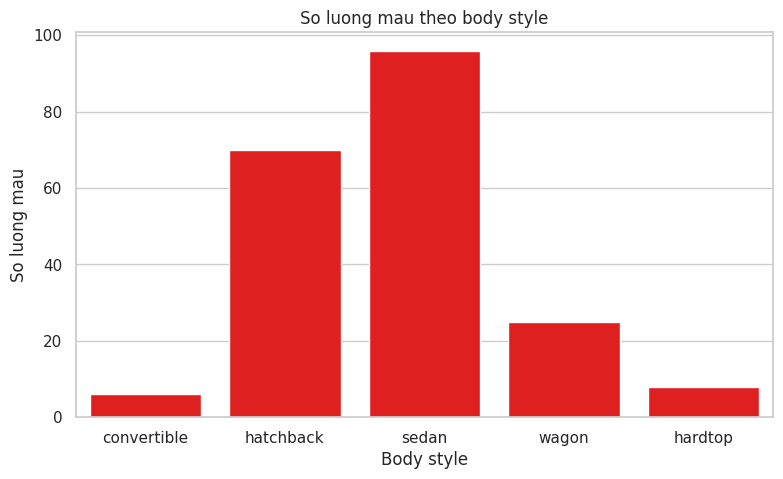

In [20]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x='body_style', color='red')
plt.title('So luong mau theo body style')
plt.xlabel('Body style')
plt.ylabel('So luong mau')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->

Dataset bị mất cân bằng vì hai nhóm hatchback và sedan chiếm đa số(từ 70 đến gần 100 mẫu xe) trong khi 3 nhóm còn lại chỉ chiếm khoảng dưới 30.

## M2.3 Price khác nhau theo body style ra sao?

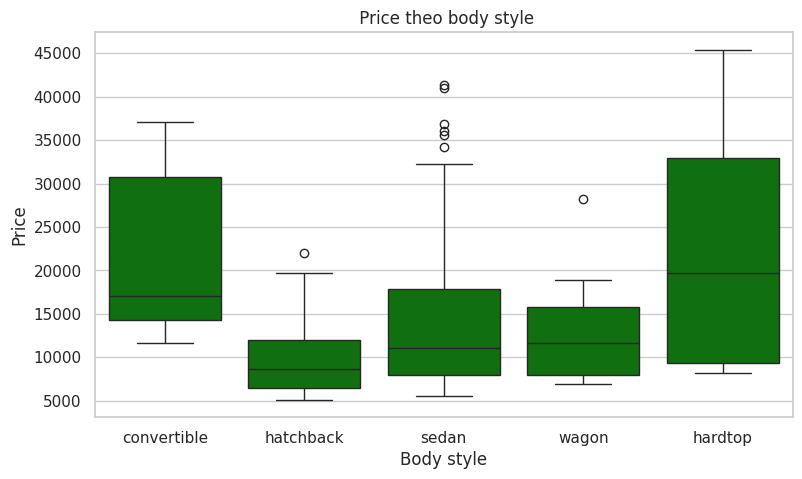

In [21]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(9, 5))
sns. boxplot(data=df_clean, x='body_style', y='price', color='green')
plt.title(' Price theo body style')
plt.xlabel('Body style')
plt.ylabel('Price')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Convertible và hardtop có mức giá cao hơn so với các loại khác. Ngược lại, Hatchback có mức giá rẻ nhất.
- Sedan có nhiều điểm outliers ở mức từ dưới 35000 đến trên 40000 cho thấy Sedan đa dạng mẫu mã. Wagon hộp ngắn và không có outliers cho thấy dòng này ổn định ở phân khúc tầm trung.

## M2.4 Engine size liên quan thế nào tới price?

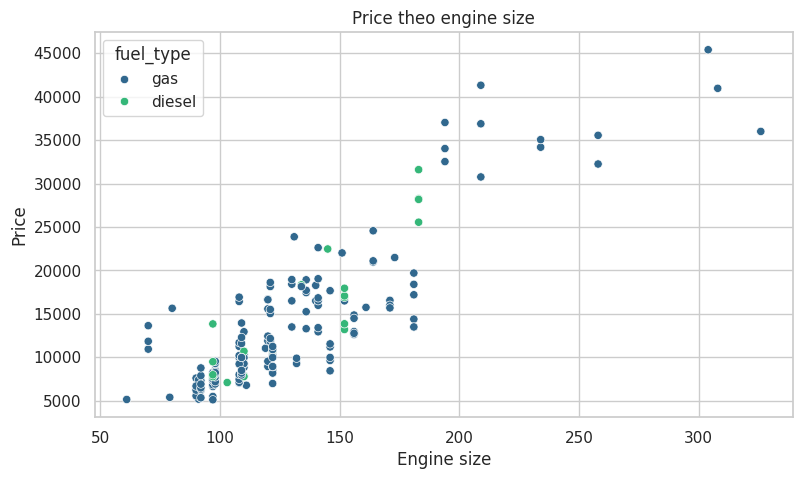

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', palette='viridis')
plt.title('Price theo engine size')
plt.xlabel('Engine size')
plt.ylabel('Price')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Những chiếc xe có engine size càng lớn thì giá càng tăng cho thấy mối tương quan tuyến tính mạnh.
- Những chiếc xe chạy xăng chiếm số lượng nhiều hơn và rải rác từ phân khúc trung đến phân khúc cao. Xe chạy diesel tập trung chủ yếu ở khúc tầm trung.

## M2.5 Các feature numeric tương quan ra sao?

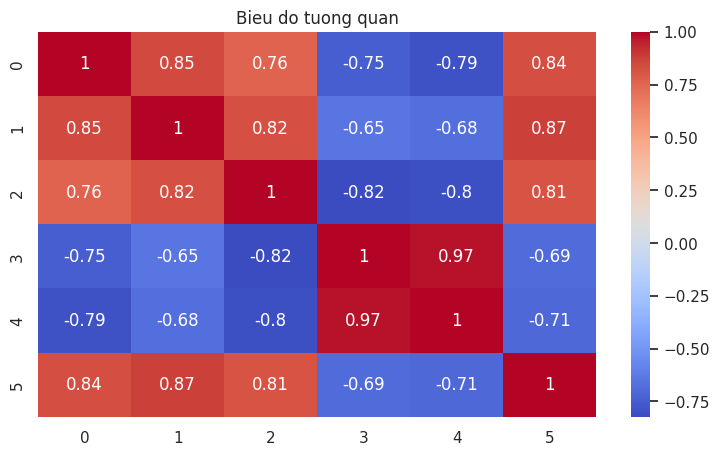

In [26]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(9, 5))
corr_matrix=np.corrcoef(X_auto, rowvar=False)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Bieu do tuong quan')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Biểu đồ đối xứng qua đường chéo chính tuy nhiên có những cặp tương quan mạnh dẫn đến đa cộng tuyến như cặp (3, 4)

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Mối quan hệ giữa symboling và price.

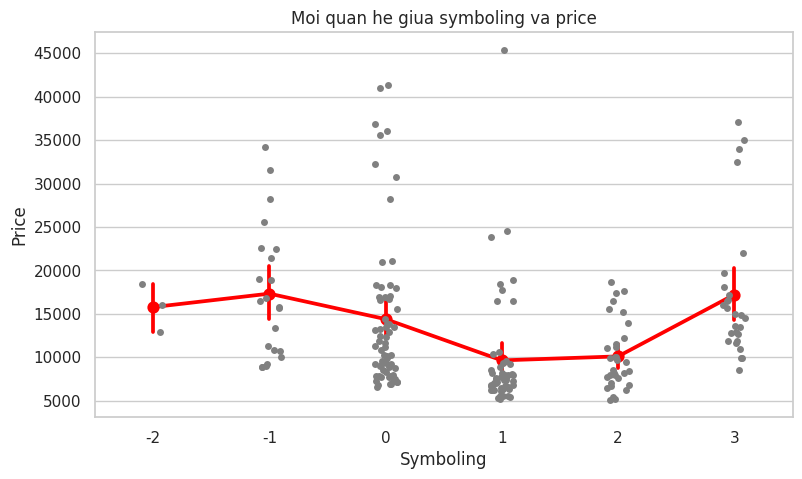

In [29]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(9, 5))
sns.stripplot(data=df_clean, x='symboling', y='price', color='gray')
sns.pointplot(data=df_clean, x='symboling', y='price', color='red')
plt. title('Moi quan he giua symboling va price')
plt.xlabel('Symboling')
plt.ylabel('Price')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Những chiếc xe có độ an toàn cao có giá trị trung vị cao hơn xe có độ an toàn thấp

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->